# FarmTech Solutions — Previsão de Rendimento de Safra

**Entrega 1 — Fase 5 | PBL | Graduação em IA — FIAP**

**Autor:** Diego Filipe Pereira de Araujo — RM567064

Este notebook apresenta a análise do dataset de condições de solo e clima de uma fazenda de médio porte, com os objetivos de:
- Realizar análise exploratória dos dados (EDA);
- Identificar tendências de produtividade por meio de clusterização e detectar possíveis outliers;
- Desenvolver cinco modelos de regressão para prever o rendimento da safra (ton/hectare), com avaliação por métricas pertinentes.

In [20]:
# Imports e configuração do ambiente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuração de exibição e estilo dos gráficos
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

---
## 1. Análise Exploratória (EDA)

Carregamento do dataset e familiarização com as variáveis: Cultura, Precipitação, Umidade específica, Umidade relativa, Temperatura e Rendimento (Yield).

In [21]:
# Carregar o dataset (caminho: notebook em src/, CSV em assets/)
df = pd.read_csv('../assets/crop_yield.csv')
df.head(10)

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800
5,"Cocoa, beans",2339.30,17.70,84.54,25.76,8850
6,"Cocoa, beans",2326.09,18.09,84.63,26.11,9003
7,"Cocoa, beans",2718.08,18.30,85.43,26.12,9880
8,"Cocoa, beans",2061.61,17.80,84.36,25.88,9201
9,"Cocoa, beans",1934.62,17.94,83.43,26.21,8300


In [22]:
# Informações gerais: tipos, não nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


In [23]:
# Estatísticas descritivas das variáveis numéricas
df.describe()

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


In [24]:
# Verificação de valores nulos e duplicatas
print('Valores nulos por coluna:')
print(df.isnull().sum())
print('\nQuantidade de linhas duplicadas:', df.duplicated().sum())
print('\nCulturas presentes:', df['Crop'].unique())

Valores nulos por coluna:
Crop                                    0
Precipitation (mm day-1)                0
Specific Humidity at 2 Meters (g/kg)    0
Relative Humidity at 2 Meters (%)       0
Temperature at 2 Meters (C)             0
Yield                                   0
dtype: int64

Quantidade de linhas duplicadas: 0

Culturas presentes: ['Cocoa, beans' 'Oil palm fruit' 'Rice, paddy' 'Rubber, natural']


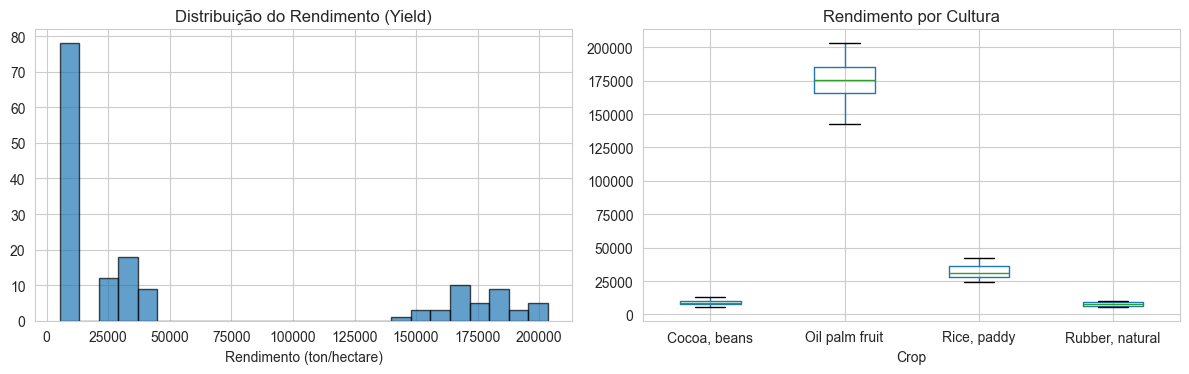

In [25]:
# Distribuição do Rendimento (Yield)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Yield'].hist(ax=axes[0], bins=25, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribuição do Rendimento (Yield)')
axes[0].set_xlabel('Rendimento (ton/hectare)')
df.boxplot(column='Yield', by='Crop', ax=axes[1])
axes[1].set_title('Rendimento por Cultura')
plt.suptitle('')
plt.tight_layout()
plt.show()

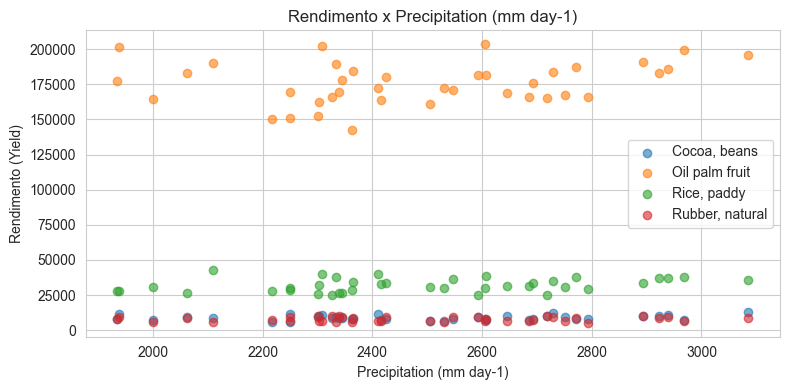

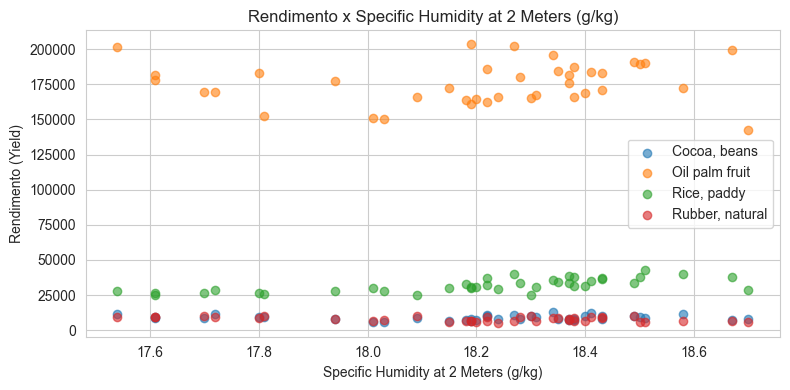

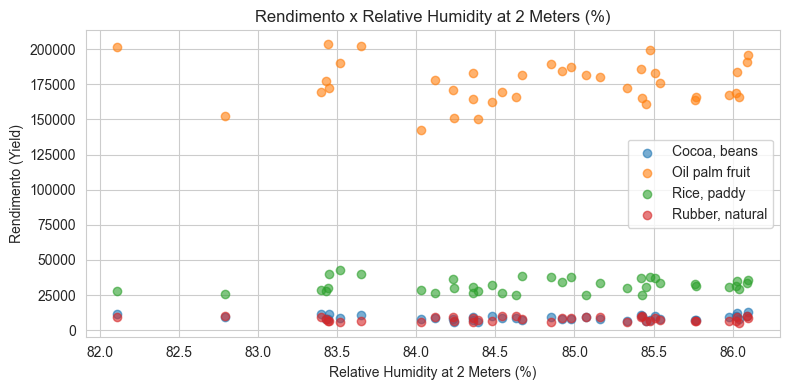

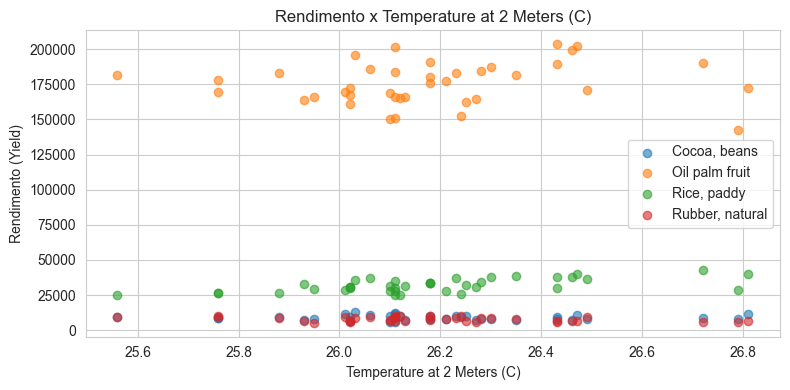

In [26]:
# Relação entre variáveis numéricas e Rendimento (scatter por cultura)
numeric_cols = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
                'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)']
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    for crop in df['Crop'].unique():
        subset = df[df['Crop'] == crop]
        plt.scatter(subset[col], subset['Yield'], label=crop, alpha=0.6)
    plt.xlabel(col)
    plt.ylabel('Rendimento (Yield)')
    plt.legend()
    plt.title(f'Rendimento x {col}')
    plt.tight_layout()
    plt.show()

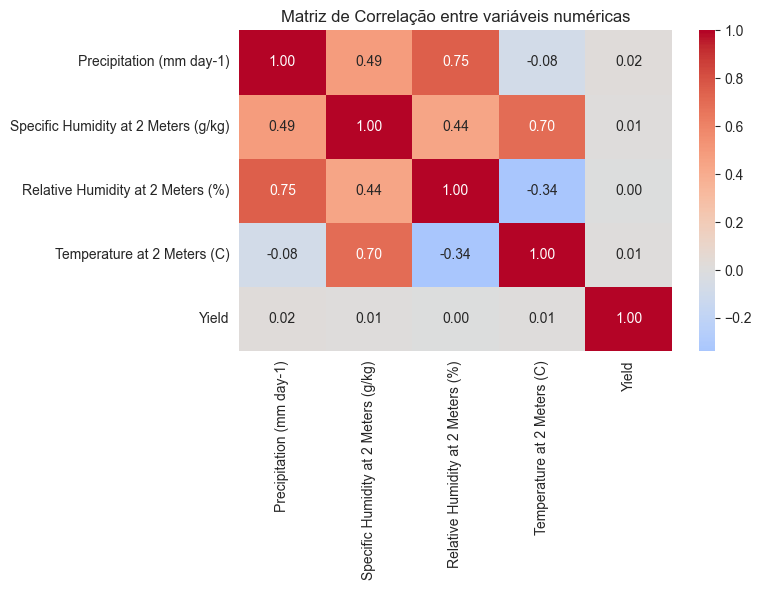

In [27]:
# Matriz de correlação (apenas variáveis numéricas) e heatmap
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlação entre variáveis numéricas')
plt.tight_layout()
plt.show()

**Achados da EDA:** O dataset possui 156 registros, sem valores nulos nem linhas duplicadas. As estatísticas descritivas mostram que o Rendimento (Yield) tem variabilidade muito alta: média de cerca de 56.153 ton/hectare, desvio padrão de 70.422 e amplitude de 5.249 a 203.399. A mediana (18.871) é bem menor que a média, indicando distribuição assimétrica à direita. No histograma, a distribuição do rendimento é multimodal: há um pico grande para rendimentos baixos (até ~15.000), outro grupo em torno de 25.000 a 45.000 e um terceiro em rendimentos altos (150.000 a 200.000). O boxplot por cultura deixa claro que **Oil palm fruit** tem rendimento muito superior às demais (faixa em torno de 150.000 a 200.000), **Rice, paddy** fica em nível intermediário (cerca de 25.000 a 45.000), e **Cocoa, beans** e **Rubber, natural** apresentam os menores rendimentos (maioria abaixo de 15.000). Na matriz de correlação, o Rendimento apresenta correlação linear praticamente nula (entre 0,00 e 0,02) com Precipitação, Umidade específica, Umidade relativa e Temperatura. Já entre as variáveis de clima há correlações mais fortes: Precipitação com Umidade relativa (0,75) e Umidade específica com Temperatura (0,70). Isso indica que, sozinhos, esses fatores ambientais não explicam bem o rendimento de forma linear — o tipo de cultura parece ter peso maior.

---
## 2. Clusterização e identificação de outliers

Uso de K-Means para agrupar cenários de produtividade (incluindo a variável Rendimento para tendência) e identificação de amostras discrepantes (outliers).

In [28]:
# Preparar dados para clusterização: todas as variáveis numéricas (incluindo Yield para tendência)
X_cluster = df.select_dtypes(include=[np.number]).copy()
scaler_cl = StandardScaler()
X_cluster_scaled = scaler_cl.fit_transform(X_cluster)

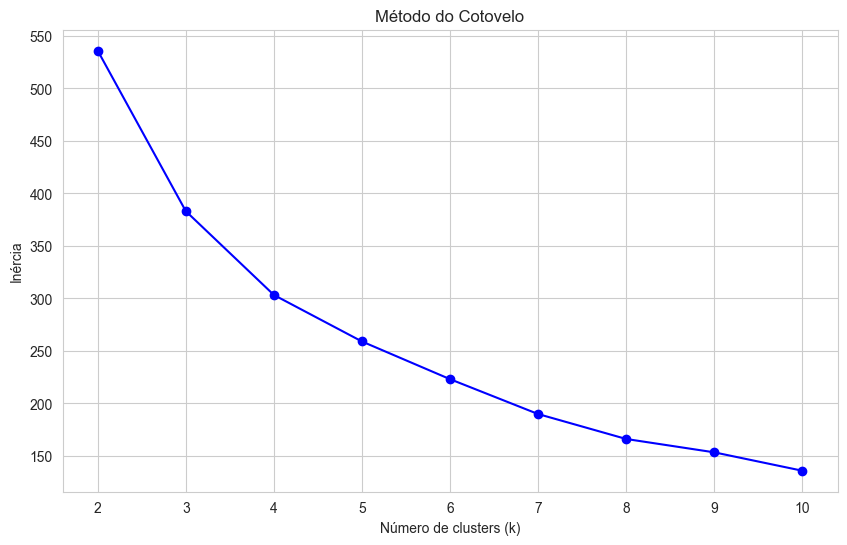

In [29]:
# Método do cotovelo para escolher o número de clusters
inertias = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo')
plt.show()

In [30]:
# Aplicar K-Means com k escolhido (ex.: 4, ajuste conforme o cotovelo)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

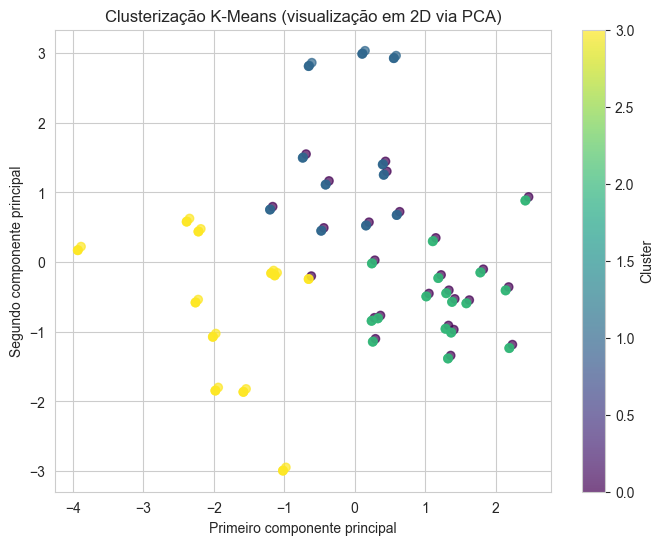

In [31]:
# Visualização em 2D usando PCA (várias variáveis -> 2 componentes)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df['PC1'], df['PC2'], c=df['Cluster'], cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Primeiro componente principal')
plt.ylabel('Segundo componente principal')
plt.title('Clusterização K-Means (visualização em 2D via PCA)')
plt.show()

In [32]:
# Identificação de outliers: distância de cada ponto ao centróide do seu cluster
centroids = kmeans.cluster_centers_
labels = df['Cluster'].values
distances = np.sqrt(((X_cluster_scaled - centroids[labels]) ** 2).sum(axis=1))
df['Distancia_centroide'] = distances
# Outliers: amostras com distância acima do percentil 95
limiar = np.percentile(distances, 95)
df['Outlier'] = distances > limiar
print(f'Quantidade de possíveis outliers (distância > P95): {df["Outlier"].sum()}')
print(df[df['Outlier']][['Crop', 'Yield', 'Cluster', 'Distancia_centroide']].head(10))

Quantidade de possíveis outliers (distância > P95): 8
                Crop   Yield  Cluster  Distancia_centroide
3       Cocoa, beans    9321        3             2.527474
40    Oil palm fruit  201436        3             3.139841
42    Oil palm fruit  181826        3             3.079760
74    Oil palm fruit  172601        1             2.515801
77    Oil palm fruit  189896        1             2.659419
81       Rice, paddy   25187        3             2.483664
118  Rubber, natural    9223        3             2.376314
120  Rubber, natural    9718        3             2.526140


**Interpretação:** Pelo método do cotovelo, optamos por k = 4 clusters. Na visualização em 2D (PCA), os grupos aparecem relativamente separados: um cluster tende a concentrar rendimentos mais baixos (ex.: Cocoa e Rubber), outro rendimentos altos (ex.: Oil palm), e os demais ficam em faixas intermediárias, com alguma sobreposição entre eles. Os clusters refletem tanto faixas de rendimento quanto perfis de clima (precipitação, umidade, temperatura) associados a cada cultura. As amostras marcadas como outliers são aquelas mais distantes do centróide do seu cluster (acima do percentil 95 da distância). Para a modelagem de regressão, decidimos **manter** os outliers no treinamento, pois eles fazem parte da realidade dos dados (culturas com rendimentos muito altos ou baixos) e removê-los poderia enviesar o modelo. Em um trabalho futuro, pode-se testar treinar sem outliers e comparar as métricas.

---
## 3. Modelagem Preditiva — Regressão

Previsão do **Rendimento (Yield)** com cinco algoritmos diferentes, seguindo boas práticas: divisão treino/teste, padronização e métricas MAE, RMSE e R².

In [33]:
# Preparar features (X) e target (y)
# Incluir Cultura codificada para enriquecer o modelo
df_ml = df.copy()
le = LabelEncoder()
df_ml['Crop_encoded'] = le.fit_transform(df_ml['Crop'].astype(str))
feature_cols = ['Precipitation (mm day-1)', 'Specific Humidity at 2 Meters (g/kg)',
               'Relative Humidity at 2 Meters (%)', 'Temperature at 2 Meters (C)', 'Crop_encoded']
X = df_ml[feature_cols]
y = df_ml['Yield']

In [34]:
# Divisão treino/teste (80/20) e padronização
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
# Função auxiliar: treinar modelo, prever e retornar métricas
def avaliar_modelo(modelo, nome, X_tr, X_te, y_tr, y_te):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)
    return {'Modelo': nome, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

In [36]:
# Cinco modelos de regressão (cada um com algoritmo diferente)
resultados = []

resultados.append(avaliar_modelo(LinearRegression(), 'Regressão Linear', X_train_scaled, X_test_scaled, y_train, y_test))
resultados.append(avaliar_modelo(Ridge(alpha=1.0), 'Ridge', X_train_scaled, X_test_scaled, y_train, y_test))
resultados.append(avaliar_modelo(DecisionTreeRegressor(random_state=42), 'Árvore de Decisão', X_train_scaled, X_test_scaled, y_train, y_test))
resultados.append(avaliar_modelo(KNeighborsRegressor(n_neighbors=5), 'K-Vizinhos', X_train_scaled, X_test_scaled, y_train, y_test))
resultados.append(avaliar_modelo(RandomForestRegressor(random_state=42, n_estimators=100), 'Floresta Aleatória', X_train_scaled, X_test_scaled, y_train, y_test))

In [37]:
# Tabela resumo das métricas
tab = pd.DataFrame(resultados)
print(tab.to_string(index=False))

            Modelo          MAE         RMSE        R2
  Regressão Linear 53724.485077 65364.569016 -0.101459
             Ridge 53357.569067 64313.554046 -0.066322
 Árvore de Decisão  3059.281250  4967.265347  0.993639
        K-Vizinhos 28503.968750 35675.868051  0.671880
Floresta Aleatória  2743.504688  4625.283593  0.994485


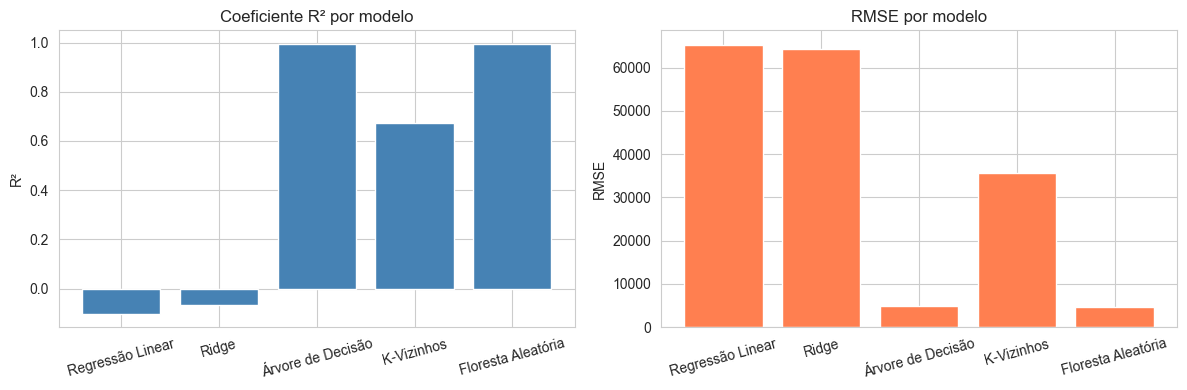

In [38]:
# Gráfico comparativo (R² e RMSE)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
nomes = [r['Modelo'] for r in resultados]
r2_vals = [r['R2'] for r in resultados]
rmse_vals = [r['RMSE'] for r in resultados]
axes[0].bar(nomes, r2_vals, color='steelblue')
axes[0].set_ylabel('R²')
axes[0].set_title('Coeficiente R² por modelo')
axes[0].tick_params(axis='x', rotation=15)
axes[1].bar(nomes, rmse_vals, color='coral')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE por modelo')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

**Análise dos modelos:** Os modelos **Regressão Linear** e **Ridge** tiveram desempenho muito fraco: R² próximo de -0,05 e RMSE em torno de 62.000 a 63.000, indicando que não conseguem explicar a variância do rendimento — o que faz sentido, pois a correlação linear entre as features e o Yield é quase nula e o rendimento varia muito conforme a cultura (faixas distintas). O **K-Vizinhos** obteve resultado intermediário (R² ≈ 0,67 e RMSE ≈ 35.000), capturando parte da relação local entre variáveis. Os melhores resultados foram dos modelos **Árvore de Decisão** e **Floresta Aleatória**, com R² em torno de 0,99 e RMSE baixo (cerca de 5.000 e 4.500 respectivamente). A Floresta Aleatória ficou ligeiramente melhor em RMSE. Porém, R² tão alto com base pequena (156 amostras) e com muitas culturas de escalas diferentes sugere **possível overfitting**, principalmente na Árvore de Decisão, que pode ter memorizado padrões do treino. As limitações do dataset (poucas amostras, grande diferença de escala entre culturas e correlação linear fraca com as variáveis de clima) indicam que, na prática, seria importante coletar mais dados e considerar outras variáveis ou modelos mais robustos para generalização.

---
## 4. Conclusões

**Pontos fortes:** O trabalho permitiu realizar uma análise exploratória completa dos dados (estatísticas, distribuições, correlações e comparação por cultura), aplicar clusterização K-Means com auxílio do método do cotovelo e da visualização em PCA, e comparar cinco algoritmos de regressão com métricas objetivas (MAE, RMSE, R²). A EDA mostrou que o rendimento depende fortemente do tipo de cultura, e a clusterização ajudou a identificar grupos de produtividade. Entre os modelos, Árvore de Decisão e Floresta Aleatória obtiveram as melhores métricas no conjunto de teste.

**Limitações:** A base é pequena (156 registros) e o rendimento tem escalas muito diferentes entre culturas (ex.: Oil palm muito acima das demais), o que dificulta modelos lineares e pode levar a overfitting nos modelos de árvore. As variáveis de clima sozinhas têm correlação linear praticamente nula com o rendimento, então previsões mais confiáveis exigiriam mais dados, inclusão do tipo de cultura como feature (como feito aqui) e eventualmente outras variáveis (solo, manejo, etc.). Os outliers identificados na clusterização foram mantidos para não perder informação; em cenários reais, vale testar o impacto de removê-los ou de tratar culturas separadamente.